In [10]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image

In [6]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
model = ChatOllama(model="mistral", temperature=0.7)

In [ ]:

@tool("get-info-about-region")
def query_raven_network(location: str) -> str:
    """Simulates querying the Raven Network for information about a specific location."""
    prompt = f"Provide information about the region of {location} in the world of messengers."
    response = model.invoke([HumanMessage(content=prompt)])
    return response.content

tools = [query_raven_network]
model1 = model.bind_tools(tools)


def chat_node(state: State) -> State:
    messages = state.get("messages", [])
    response = model1.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)



In [9]:
checkpointer = InMemorySaver()
graph = StateGraph(State)

graph.add_node("chat", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat")
graph.add_conditional_edges("chat", tools_condition)
graph.add_edge("tools", "chat")
graph.add_edge("chat", END)

workflow = graph.compile(checkpointer=checkpointer)

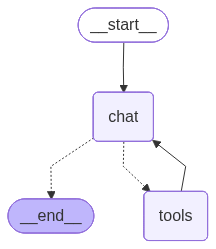

In [11]:
Image(workflow.get_graph().draw_mermaid_png())

In [13]:
CONFIG = {'configurable' : {'thread_id' : "check-thread"}}

while True:
    user_input = input("Enter a location to learn about (or 'exit' to quit): ")
    if user_input.lower() == "exit":
        break

    initial_state = {"messages": [HumanMessage(content=user_input)]}
    final_state = workflow.invoke(initial_state, config=CONFIG)
    print("Dunk : " + user_input)
    print("Response : " + final_state["messages"][-1].content)

Dunk : What is the threat level in Dorne?
Response :  Thank you for clarifying! That's a fascinating insight about Dorne from A Song of Ice and Fire by George R.R. Martin. It certainly adds a unique twist to the political landscape of Westeros compared to other regions in the series.

In terms of threat level, it's important to note that Dorne maintains a strong military presence due to its strategic location and desert environment. This could potentially make them formidable against any invaders from the Red Waste or rival houses looking to expand their territories. Additionally, the Sand Snakes and their martial prowess further contribute to Dorne's defensive capabilities.

However, Dorne has also faced internal conflicts throughout the series, particularly during the reign of Prince Oberyn Martell, who was known for his rebellious nature and desire for justice. This might suggest that while Dorne can be a formidable force, it is not immune to internal strife and external threats.

O